In [1]:


import os                              # For navigating the file system (folders, paths)
import random                          # To pick random images for visualisation
import zipfile                         # To extract the dataset zip file from Google Drive
import numpy as np                     # Numerical operations (array math, argmax, etc.)
import matplotlib.pyplot as plt        # Plotting graphs and displaying images
import tensorflow as tf                # Deep learning framework
from tensorflow import keras           # High-level Keras API inside TensorFlow
from tensorflow.keras import layers    # All Keras layer types (Conv2D, Dense, etc.)

# Model building utilities
from tensorflow.keras.models import Sequential, Model


from tensorflow.keras.layers import (
    Conv2D,                # 2D Convolutional layer — learns spatial features from images
    MaxPooling2D,          # Reduces spatial size by keeping only the max value in each window
    Flatten,               # Converts 3D feature maps into 1D vector for Dense layers
    Dense,                 # Fully connected layer — every neuron connects to every input
    BatchNormalization,    # Normalises activations for stable, faster training
    Dropout,               # Randomly zeros out neurons to prevent overfitting
    Activation,            # Applies activation function (e.g. ReLU) as a separate layer
    GlobalAveragePooling2D # Reduces each feature map to a single number (used in VGG16 head)
)

from PIL import Image, UnidentifiedImageError  # PIL: Python Imaging Library for opening/verifying images

# Evaluation metrics from scikit-learn
from sklearn.metrics import (
    classification_report,   # Per-class precision, recall, F1-score
    confusion_matrix,        # Matrix showing correct and misclassified predictions per class
    ConfusionMatrixDisplay   # Helper to plot the confusion matrix as a heatmap
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# Set your dataset path
BASE_DIR = '/content/drive/MyDrive/FruitinAmazon'
train_dir = os.path.join(BASE_DIR, 'train')
test_dir  = os.path.join(BASE_DIR, 'test')

print(os.listdir(train_dir))

# The extracted zip might have different nested structures depending on how it was zipped.
# This function walks through all subdirectories to find a folder by name.
def find_subdir(root, name):
    for dirpath, dirnames, _ in os.walk(root):
        if name in dirnames:
            return os.path.join(dirpath, name)
    return None  # Return None if not found


print(f"Train directory: {train_dir}")
print(f"Test directory:  {test_dir}")

['.DS_Store', 'guarana', 'graviola', 'cupuacu', 'pupunha', 'acai', 'tucuma']
Train directory: /content/drive/MyDrive/FruitinAmazon/train
Test directory:  /content/drive/MyDrive/FruitinAmazon/test


In [4]:
# ============================================================
# CELL 3 — Task 1a: Read Dataset Directory and Extract Class Names


print("TASK 1a: Verifying Dataset Directory")
print("*" * 45)

# os.listdir() returns a list of all files and folders inside train_dir
class_names = sorted(os.listdir(train_dir))

# Check whether any class directories were found
if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")



TASK 1a: Verifying Dataset Directory
*********************************************
Found 7 classes: ['.DS_Store', 'acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [5]:


print("TASK 1b: Checking for corrupted images")
print("*" * 45)

corrupted_images = []   # Empty list to store paths of any corrupted images found

# Loop through every class folder
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)  # Full path to this class folder

    if os.path.isdir(class_path):
        images = os.listdir(class_path)

        for img_name in images:            # Check each file one by one
            img_path = os.path.join(class_path, img_name)  # Full path to this image

            try:
                with Image.open(img_path) as img:  # Attempt to open the image
                    img.verify()                   # img.verify() checks file integrity without
                                                   # fully decoding — fast and lightweight
            except (IOError, UnidentifiedImageError):
                # IOError: file is unreadable (e.g. empty or wrong format)
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

# Final report
if corrupted_images:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")
else:
    print("\nNo corrupted images found. Dataset is clean.")

TASK 1b: Checking for corrupted images
*********************************************

No corrupted images found. Dataset is clean.


In [6]:

#  Task 1c : Class Balance Check


print("TASK 1c (Week 6 New): Class Distribution / Balance Check")
print("*" * 45)

class_counts = {}  # Dictionary: key = class name, value = number of valid images

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        # List comprehension: only count files that are valid image formats
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        class_counts[class_name] = len(images)  # Store the count

# Print a formatted table
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")  # <25 = left-align in 25 chars, >15 = right-align in 15
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


plt.show()


TASK 1c (Week 6 New): Class Distribution / Balance Check
*********************************************

Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


TASK 1d: Visualising one random image per class
*********************************************
Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']



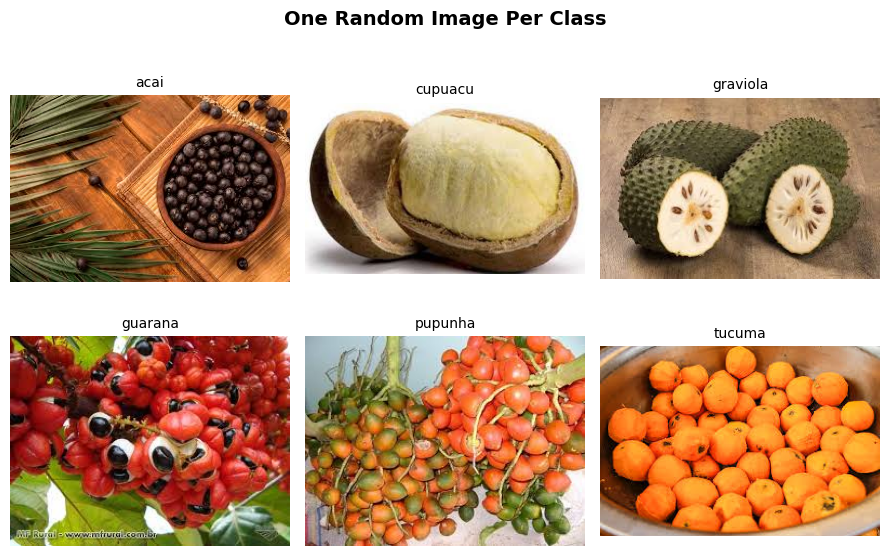

In [7]:

# Task 1d: Visualise One Random Image Per Class
# WHY: Before training, we should visually verify that images are loading correctly,


print("TASK 1d: Visualising one random image per class")
print("*" * 45)

# Get only the subdirectories inside train_dir n ignores any stray files
class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])
print(f"Classes found: {class_dirs}\n")

sample_images = []
sample_labels = []

for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)

    # List only valid image files (filter out hidden files, text files, etc.)
    all_images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpeg', '.jpg', '.png'))
    ]

    if all_images:  # Only proceed if the folder is not empty
        chosen = random.choice(all_images)
        sample_images.append(os.path.join(cls_path, chosen))
        sample_labels.append(cls)

# --- Build a grid layout ---
num_images = len(sample_images)
num_cols   = (num_images + 1) // 2   # Ceiling division: 6 classes → 3 columns
num_rows   = 2                        # Always 2 rows as required by the worksheet

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3, 6))
axes = axes.flatten()  # Convert 2D array of axes into 1D for easy indexing

for i, (image_path, label) in enumerate(zip(sample_images, sample_labels)):
    img = Image.open(image_path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=10)
    axes[i].axis("off")

# Hide any unused subplot cells (e.g. if num_classes is odd)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("One Random Image Per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("task1d_sample_images.png", dpi=150)
plt.show()

In [8]:
#Task2: Data Generation, Augmentaion and Pre-processing
# ============================================================
# CELL 7 — Task 2a: Load Train / Validation / Test Datasets
# WHY: We use image_dataset_from_directory because it automatically:
#   - Infers class labels from folder names
#   - Resizes all images to a consistent size
#   - Splits into training and validation subsets
#   - Batches images for efficient GPU processing


print("TASK 2a: Loading datasets")
print("=" * 35)

img_height       = 128
img_width        = 128
batch_size       = 16
validation_split = 0.2

# --- Training Dataset ---
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',          # Labels as integers (0, 1, 2 ...) — needed for sparse_categorical_crossentropy
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = batch_size,
    shuffle          = True,
    validation_split = validation_split,
    subset           = 'training',
    seed             = 123
)

# --- Validation Dataset (from the same train folder, different 20% split) ---
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = batch_size,
    shuffle          = False,
    validation_split = validation_split,
    subset           = 'validation',
    seed             = 123
)

# --- Test Dataset (from separate test folder — never seen during training) ---
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (img_height, img_width),
    interpolation = 'nearest',
    batch_size    = batch_size,
    shuffle       = False,
    seed          = 123
)

# Extract class names and count (from training dataset)
class_names = train_ds.class_names
num_classes = len(class_names)

print(f"Classes : {class_names}")
print(f"Total   : {num_classes} classes")

TASK 2a: Loading datasets
Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Total   : 6 classes


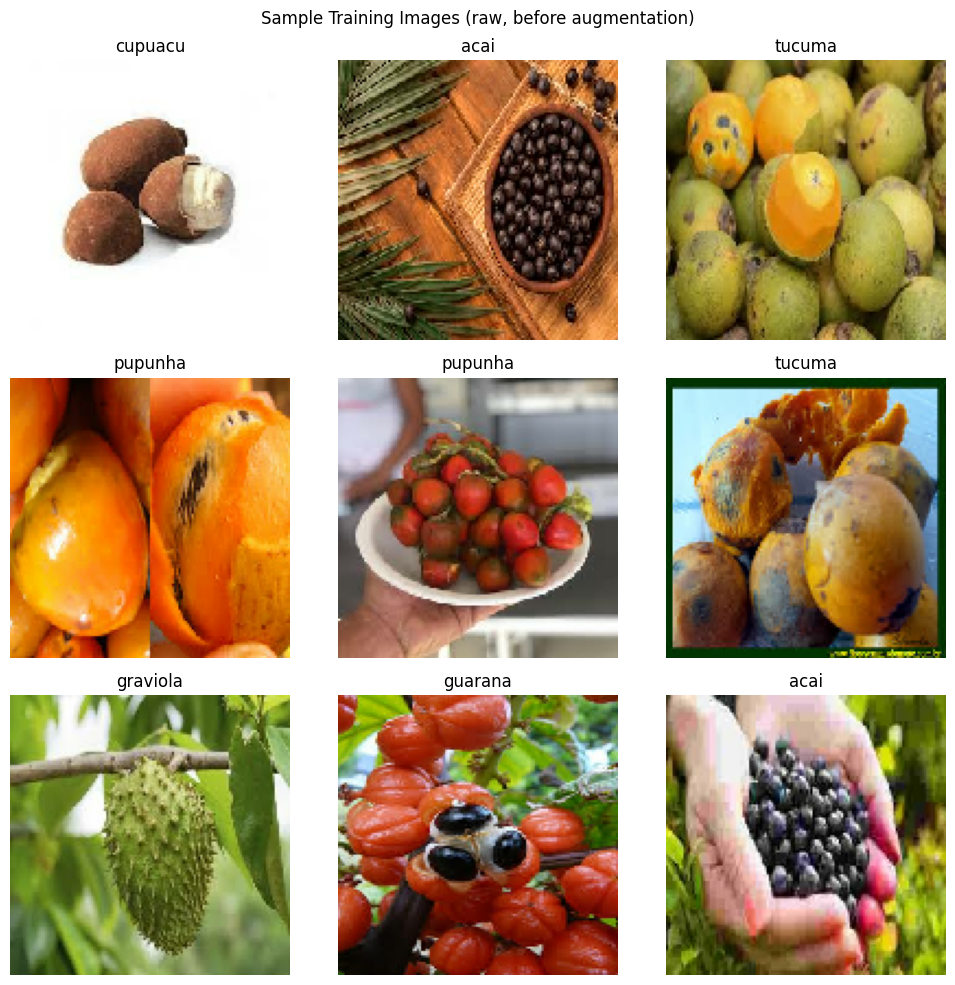

In [9]:
# ============================================================
# CELL 8 — Visualise a batch from the training dataset
# SAME as Week 5 — confirms images and labels look correct before training
# ============================================================

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Training Images (raw, before augmentation)", fontsize=12)
plt.tight_layout()
plt.show()

TASK 2b (Week 6 New): Data Augmentation Definition
Augmentation layers defined: RandomFlip, RandomRotation, RandomZoom


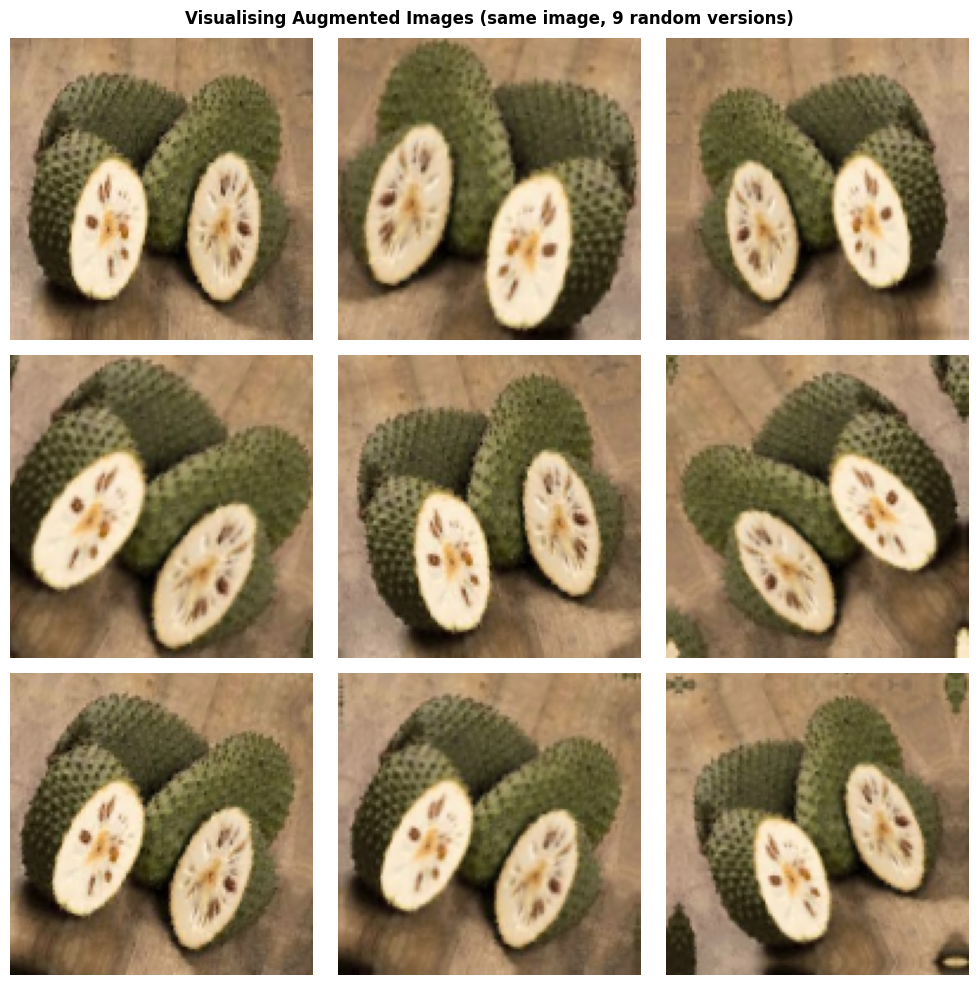

Augmented images saved → task2b_augmented_images.png


In [14]:
#  Task 2b: Define Data Augmentation


print("TASK 2b (Week 6 New): Data Augmentation Definition")
print("=" * 45)

# Define a list of augmentation layers
# Each layer applies a RANDOM transformation — different every time an image is seen
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),  # Randomly flips image left-right (50% chance)

    layers.RandomRotation(0.1),
                                       # Simulates photos taken at slightly different angles
    layers.RandomZoom(0.1),
                                       # Simulates camera distance variation

]

# Create a Sequential model for augmentation to apply layers efficiently
augmenter = keras.Sequential(data_augmentation_layers)

# A function that applies all augmentation layers sequentially to a batch of images
def augment_data(image, label):
    # Apply augmentation to the image
    image = augmenter(image)
    # Return the augmented image and its original label
    return image, label

print("Augmentation layers defined: RandomFlip, RandomRotation, RandomZoom")

# --- Visualise augmented images to verify the augmentation is working ---
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):                   # Show 9 augmented versions of the same first image
        augmented_images, _ = augment_data(images, tf.zeros(1)) # Pass dummy label for visualization
        ax = plt.subplot(3, 3, i + 1)                  # Create 3x3 grid
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))  # Show first image in batch
        # .astype("uint8"): converts float values back to 0-255 integers for display
        plt.axis("off")

plt.suptitle("Visualising Augmented Images (same image, 9 random versions)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("task2b_augmented_images.png", dpi=150)
plt.show()
print("Augmented images saved → task2b_augmented_images.png")

In [15]:

# Task 3: Build the Improved CNN (Week 6 Architecture)


print("TASK 3: Building the Improved CNN (Week 6)")
print("=" * 45)

 #Build model
model = keras.Sequential([
    # Normalization should be the first layer now that augmentation is in the data pipeline
    layers.Rescaling(1./255),

    # 1st Conv Block
    layers.Conv2D(32, (3, 3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # 2nd Conv Block
    layers.Conv2D(64, (3, 3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # 3rd Conv Block
    layers.Conv2D(128, (3, 3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # 4th Conv Block
    layers.Conv2D(256, (3, 3), padding='same', activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Flatten
    layers.Flatten(),

    # Fully Connected layers
    layers.Dense(512, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(256, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(128, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(64, activation=None),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(num_classes, activation='softmax')
])


# Model summary
model.summary()


TASK 3: Building the Improved CNN (Week 6)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

TASK 4: Compiling and Training the Model
Model compiled.

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1830 - loss: 2.2829  
Epoch 1: val_loss improved from None to 1.80716, saving model to best_model_week6.h5



Epoch 1: finished saving model to best_model_week6.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.1806 - loss: 2.2521 - val_accuracy: 0.0000e+00 - val_loss: 1.8072
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1955 - loss: 2.2804
Epoch 2: val_loss improved from 1.80716 to 1.80348, saving model to best_model_week6.h5



Epoch 2: finished saving model to best_model_week6.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.2222 - loss: 2.2465 - val_accuracy: 0.0000e+00 - val_loss: 1.8035
Epoch 3/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2943 - loss: 2.0394
Epoch 3: val_loss improved from 1.80348 to 1.74211, saving model to best_model_week6.h5



Epoch 3: finished saving model to best_model_week6.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.2222 - loss: 2.1230 - val_accuracy: 0.0000e+00 - val_loss: 1.7421
Epoch 4/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2487 - loss: 2.1704 
Epoch 4: val_loss improved from 1.74211 to 1.73486, saving model to best_model_week6.h5



Epoch 4: finished saving model to best_model_week6.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.2222 - loss: 2.1419 - val_accuracy: 0.0000e+00 - val_loss: 1.7349
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2094 - loss: 2.2931
Epoch 5: val_loss did not improve from 1.73486
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.2083 - loss: 2.1360 - val_accuracy: 0.0000e+00 - val_loss: 1.7463
Epoch 6/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3034 - loss: 1.9908 
Epoch 6: val_loss did not improve from 1.73486
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2361 - loss: 2.1019 - val_accuracy: 0.0000e+00 - val_loss: 1.7625
Epoch 7/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2839 - loss: 2.0992
Epoch 7: val_loss did not improve from 1.73486
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2500 - loss: 2.0245 - val_accuracy: 0.0000e+00 - val_loss: 1.8046
Epoch 8/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2318 - loss: 1


Epoch 15: finished saving model to best_model_week6.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.3194 - loss: 1.6459 - val_accuracy: 0.0000e+00 - val_loss: 1.7292
Epoch 16/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2983 - loss: 1.9337
Epoch 16: val_loss improved from 1.72925 to 1.68284, saving model to best_model_week6.h5



Epoch 16: finished saving model to best_model_week6.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.2778 - loss: 1.9049 - val_accuracy: 0.0000e+00 - val_loss: 1.6828
Epoch 17/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2972 - loss: 1.9882
Epoch 17: val_loss improved from 1.68284 to 1.63979, saving model to best_model_week6.h5



Epoch 17: finished saving model to best_model_week6.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.2778 - loss: 1.8753 - val_accuracy: 0.0000e+00 - val_loss: 1.6398
Epoch 18/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4323 - loss: 1.6526
Epoch 18: val_loss did not improve from 1.63979
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3611 - loss: 1.6297 - val_accuracy: 0.0000e+00 - val_loss: 1.6442
Epoch 19/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2904 - loss: 1.7927
Epoch 19: val_loss did not improve from 1.63979
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3056 - loss: 1.7520 - val_accuracy: 0.0000e+00 - val_loss: 1.6552
Epoch 20/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3438 - loss: 1.6745
Epoch 20: val_loss did not improve from 1.63979
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3750 - loss: 1.5567 - val_accuracy: 0.0000e+00 - val_loss: 1.6653
Epoch 21/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4193 - 


Epoch 21: finished saving model to best_model_week6.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.3472 - loss: 1.7069 - val_accuracy: 0.0000e+00 - val_loss: 1.6383
Epoch 22/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3924 - loss: 1.5150
Epoch 22: val_loss improved from 1.63833 to 1.63480, saving model to best_model_week6.h5



Epoch 22: finished saving model to best_model_week6.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step - accuracy: 0.3472 - loss: 1.5787 - val_accuracy: 0.0000e+00 - val_loss: 1.6348
Epoch 23/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3597 - loss: 1.5713
Epoch 23: val_loss did not improve from 1.63480
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3194 - loss: 1.5832 - val_accuracy: 0.0000e+00 - val_loss: 1.7372
Epoch 24/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3271 - loss: 1.6309
Epoch 24: val_loss did not improve from 1.63480
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2917 - loss: 1.6153 - val_accuracy: 0.0000e+00 - val_loss: 1.8884
Epoch 25/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4010 - loss: 1.5311
Epoch 25: val_loss did not improve from 1.63480
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3472 - loss: 1.5319 - val_accuracy: 0.0000e+00 - val_loss: 2.0530
Epoch 26/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4440 - 

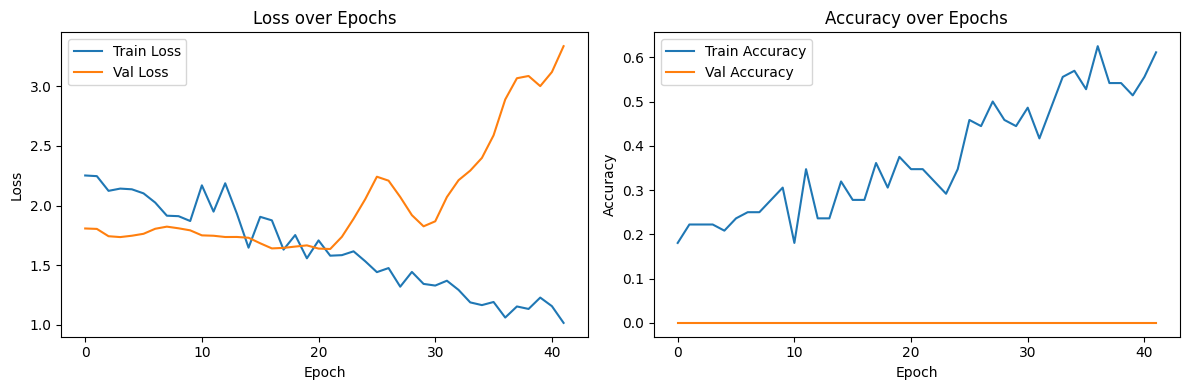

Training curves saved → task4_training_curves_week6.png


In [16]:
# ============================================================
# CELL 10 — Task 4: Compile and Train the Model
# ============================================================

print("TASK 4: Compiling and Training the Model")
print("=" * 45)

# Apply data augmentation to the training dataset using the 'augment_data' function
# defined in the previous cell. We also cache and prefetch for performance.
train_ds_augmented = train_ds.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_augmented = train_ds_augmented.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Cache and prefetch the validation dataset as well
val_ds_processed = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# model.compile() configures the training process
model.compile(
    optimizer = 'adam',
    # Adam (Adaptive Moment Estimation): Adjusts the learning rate individually for each
    # parameter based on gradients. Fast, reliable, and the standard choice.

    loss = 'sparse_categorical_crossentropy',
    # This loss function is used when:
    #   - It's a multi-class problem (more than 2 classes)
    #   - Labels are integers (0, 1, 2...) — 'sparse' means we don't need one-hot encoding
    # It measures how far the model's predicted probabilities are from the true label.

    metrics = ['accuracy']
    # Accuracy: percentage of correct predictions — easy to interpret
)
print("Model compiled.\n")

# --- Callbacks: special actions taken during training ---
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath       = 'best_model_week6.h5',  # Save to this file
        monitor        = 'val_loss',    # Watch validation loss (not training loss)
        save_best_only = True,          # Only overwrite if validation loss IMPROVED
        verbose        = 1              # Print a message whenever the model is saved
        # WHY: Training loss always decreases, but val_loss tells us true generalisation.
        # We save the model at its best generalisation point, not its last epoch.
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor              = 'val_loss',  # Watch validation loss
        patience             = 20,          # Stop if no improvement for 15 consecutive epochs
        verbose              = 1,
        restore_best_weights = True         # When stopping, revert to the best weights seen
        # WHY patience=15: Gives the model enough time to escape local plateaus
        # while still stopping before severe overfitting.
    )
]

# model.fit() runs the training loop
history = model.fit(
    train_ds_augmented,     # Use the augmented training dataset
    validation_data = val_ds_processed,  # Use the processed validation dataset
    epochs          = 250,     # Maximum number of full passes through the training data
    callbacks       = callbacks  # Apply our ModelCheckpoint and EarlyStopping
    # EarlyStopping will stop before 250 if val_loss stops improving
)

# --- Plot Training Curves ---
# These plots help diagnose overfitting (train accuracy >> val accuracy) or
# underfitting (both accuracies are low)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))  # Two side-by-side plots

# Loss curves
ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy curves
ax2.plot(history.history['accuracy'],     label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig("task4_training_curves_week6.png", dpi=150)
plt.show()
print("Training curves saved → task4_training_curves_week6.png")

In [17]:
# ============================================================
# CELL 11 — Task 5: Evaluate the Model on the Test Set
# WHY: We evaluate on a SEPARATE test set that was never seen during training or validation.
# This gives an unbiased measure of how well the model generalises to truly new data.
# ============================================================

print("TASK 5: Evaluating on the test set")
print("=" * 35)

# model.evaluate() returns loss and accuracy on the given dataset
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
# verbose=1 prints a progress bar and results

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

TASK 5: Evaluating on the test set
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 6s/step - accuracy: 0.1667 - loss: 2.0973

Test Loss     : 2.0973
Test Accuracy : 0.1667


In [18]:
# ============================================================
# CELL 12 — Task 6: Save and Load the Model
# WHY SAVE: After training (which can take hours), we save the model so we don't
# need to retrain. The .h5 format stores architecture, weights, and optimizer state.
# WHY LOAD AND RE-EVALUATE: This verifies the saved model is identical to the trained one.
# ============================================================

print("TASK 6: Saving and loading the model")
print("=" * 35)

# Save the trained model to an HDF5 (.h5) file
model.save('final_model_week6.h5')
# This saves: model architecture, all weights, optimizer state
print("Model saved → final_model_week6.h5")

# Load the model back from disk
loaded_model = tf.keras.models.load_model('final_model_week6.h5', custom_objects = {'data_augmentation': data_augmentation})
# load_model reconstructs the full model including custom Lambda layers
print("Model loaded successfully.")

# Re-evaluate the loaded model — results should match the original model
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"\nLoaded Model Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy : {loaded_acc:.4f}")

TASK 6: Saving and loading the model
Model saved → final_model_week6.h5


Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 609ms/step - accuracy: 0.1667 - loss: 2.0973

Loaded Model Test Loss     : 2.0973
Loaded Model Test Accuracy : 0.1667


TASK 7: Predictions, Classification Report & Confusion Matrix

Classification Report:

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.17      1.00      0.29         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.03      0.17      0.05        30
weighted avg       0.03      0.17      0.05        30


Confusion Matrix:



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


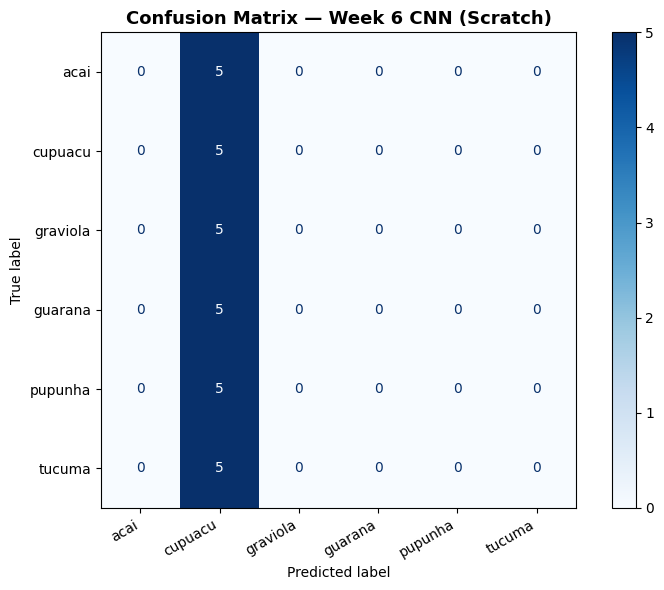

Confusion matrix saved → task7_confusion_matrix_cnn.png


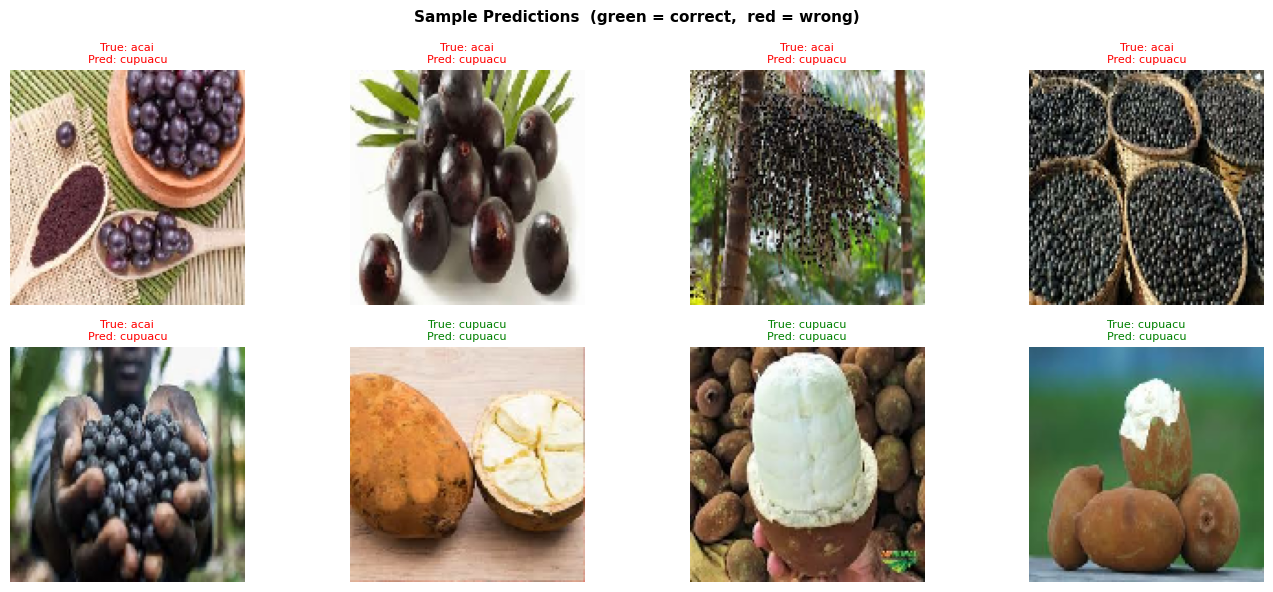

Predictions grid saved → task7_predictions_week6.png


In [19]:
# ============================================================
# CELL 13 — Task 7: Predictions, Classification Report & Confusion Matrix
# WHY CLASSIFICATION REPORT: Accuracy can be misleading if the dataset is imbalanced.
#   The report shows precision, recall, and F1-score PER CLASS.
#   - Precision: Of all images predicted as class X, how many actually were X?
#   - Recall: Of all actual class X images, how many were correctly predicted?
#   - F1-score: Harmonic mean of precision and recall — the overall class quality.
# WHY CONFUSION MATRIX: Shows which classes the model confuses with each other.
#   - Diagonal = correct predictions
#   - Off-diagonal = mistakes (which class was confused for which)
# ============================================================

print("TASK 7: Predictions, Classification Report & Confusion Matrix")
print("=" * 55)

# --- Collect all predictions and true labels from the entire test set ---
all_preds  = []   # Will store predicted class indices
all_labels = []   # Will store true class indices

for images, labels in test_ds:   # Iterate through every batch in the test set
    preds = loaded_model.predict(images, verbose=0)
    # preds shape: (batch_size, num_classes) — probability for each class

    all_preds.extend(np.argmax(preds, axis=1))
    # np.argmax: returns the INDEX of the highest probability (= predicted class)
    # axis=1 means find the max along each row (each image)

    all_labels.extend(labels.numpy())
    # .numpy() converts TensorFlow tensor to NumPy array for sklearn compatibility

# Convert lists to NumPy arrays for sklearn functions
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Classification Report ---
print("\nClassification Report:\n")
print(classification_report(
    all_labels,          # True labels
    all_preds,           # Predicted labels
    target_names=class_names  # Use actual class names instead of 0,1,2...
))

# --- Confusion Matrix ---
print("\nConfusion Matrix:\n")
cm = confusion_matrix(all_labels, all_preds)
# cm[i][j] = number of images of true class i that were predicted as class j
# Diagonal entries are correct predictions
# Off-diagonal entries are misclassifications

# Plot the confusion matrix as a colour-coded heatmap
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names  # Show class names on axes
)
disp.plot(
    cmap='Blues',       # Blue colour map: darker = higher count
    ax=ax,
    colorbar=True       # Show the colour scale bar
)
ax.set_title("Confusion Matrix — Week 6 CNN (Scratch)", fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')   # Rotate x-axis labels for readability
plt.tight_layout()
plt.savefig("task7_confusion_matrix_cnn.png", dpi=150)
plt.show()
print("Confusion matrix saved → task7_confusion_matrix_cnn.png")

# --- Visual Prediction Grid (green = correct, red = wrong) ---
sample_imgs = []
sample_true = []
sample_pred = []

for images, lbls in test_ds.take(1):   # Take ONE batch from test set
    preds = loaded_model.predict(images, verbose=0)
    pred_idx = np.argmax(preds, axis=1)  # Get predicted class index for each image
    for i in range(min(8, len(images))): # Show up to 8 images
        sample_imgs.append(images[i].numpy())           # Store raw image array
        sample_true.append(class_names[lbls[i]])        # True class name
        sample_pred.append(class_names[pred_idx[i]])    # Predicted class name

fig, axes = plt.subplots(2, 4, figsize=(14, 6))   # 2 rows x 4 columns = 8 images
axes = axes.flatten()

for i in range(len(sample_imgs)):
    axes[i].imshow(sample_imgs[i].astype("uint8"))  # Display image
    colour = "green" if sample_true[i] == sample_pred[i] else "red"
    # Green title = correct prediction, Red title = wrong prediction
    axes[i].set_title(
        f"True: {sample_true[i]}\nPred: {sample_pred[i]}",
        color=colour, fontsize=8
    )
    axes[i].axis("off")

plt.suptitle("Sample Predictions  (green = correct,  red = wrong)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("task7_predictions_week6.png", dpi=150)
plt.show()
print("Predictions grid saved → task7_predictions_week6.png")

In [20]:
#Task2 TRansfer learning with VGG16

# ============================================================
# CELL 14 — Transfer Learning Step 1: Load VGG16 (without top layer)
# WHY include_top=False:
#   VGG16's 'top' is its final Dense classification layers (for 1000 ImageNet classes).
#   We don't want those — we need our OWN output layer for 6 fruit classes.
#   So we load only the convolutional feature extractor part.
# ============================================================

print("TRANSFER LEARNING — Step 1: Loading VGG16")
print("=" * 45)

from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights     = 'imagenet',            # Load weights pre-trained on ImageNet
                                          # (downloads automatically if not cached)
    include_top = False,                  # Exclude the final Dense layers
    input_shape = (img_height, img_width, 3)  # Our images are 128x128x3
)

print(f"VGG16 loaded. Total layers: {len(base_model.layers)}")
base_model.summary()   # Shows all VGG16 layers and their parameter counts

TRANSFER LEARNING — Step 1: Loading VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
VGG16 loaded. Total layers: 19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# ============================================================
# CELL 15 — Transfer Learning Step 2: Freeze All VGG16 Layers


print("TRANSFER LEARNING — Step 2: Freezing base model layers")
print("=" * 45)

for layer in base_model.layers:
    layer.trainable = False
    # Setting trainable=False means: during backpropagation,
    # gradients will NOT be computed for this layer's weights.
    # The weights stay exactly as they were from ImageNet training.

# Count and report frozen layers
frozen_count = sum(1 for l in base_model.layers if not l.trainable)
print(f"Frozen {frozen_count} layers. Only the custom output head will be trained.")

TRANSFER LEARNING — Step 2: Freezing base model layers
Frozen 19 layers. Only the custom output head will be trained.


In [22]:
# ============================================================
# CELL 16 — Transfer Learning Steps 3 & 4: Add Custom Head and Build Final Model
# WHY preprocess_input:
#   VGG16 was trained with a SPECIFIC preprocessing:
#   - Convert RGB → BGR (reverse channel order)
#   - Zero-centre each channel using ImageNet mean (not divide by 255)
#   If we feed raw or /255 images, VGG16 sees a completely different input
#   distribution than what it was trained on — features will be wrong.
#   preprocess_input applies exactly what VGG16 expects.
# WHY GlobalAveragePooling2D:
#   VGG16's output is a 3D feature map (spatial x spatial x channels).
#   GlobalAveragePooling2D computes the average of each channel, giving a 1D vector.
#   This is more compact than Flatten and reduces overfitting.
# ============================================================

print("TRANSFER LEARNING — Steps 3 & 4: Adding custom head")
print("=" * 45)

from tensorflow.keras.applications.vgg16 import preprocess_input

# Using Functional API (not Sequential) because we need to access base_model.output
inputs = keras.Input(shape=(img_height, img_width, 3))  # Define input shape

# Apply VGG16-specific preprocessing
# Lambda wraps preprocess_input as a Keras layer
x = layers.Lambda(preprocess_input)(inputs)

# Pass through frozen VGG16 base (training=False ensures BatchNorm layers in VGG16
# use stored statistics, not batch statistics — important when layers are frozen)
x = base_model(x, training=False)

# GlobalAveragePooling: reduce (4, 4, 512) → (512,)
# Takes the average of each feature map — avoids overfitting vs Flatten
x = GlobalAveragePooling2D()(x)

# Custom Dense layers (our classification head)
x = Dense(1024, activation='relu')(x)  # 1024 neurons to combine VGG16 features
x = Dropout(0.5)(x)                    # 50% dropout to prevent overfitting in dense layer
x = Dense(256, activation='relu')(x)   # Reduce to 256 neurons
x = Dropout(0.3)(x)                    # 30% dropout

# Output layer: one neuron per fruit class with softmax
outputs = Dense(num_classes, activation='softmax')(x)

# Build the complete model: inputs → preprocessing → VGG16 → custom head → outputs
vgg_model = Model(inputs=inputs, outputs=outputs)
vgg_model.summary()

TRANSFER LEARNING — Steps 3 & 4: Adding custom head


Model: "functional_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,503,942 (59.14 MB)

 Trainable params: 789,254 (3.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

TRANSFER LEARNING — Step 5: Compile and Train
Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1056 - loss: 15.0900  
Epoch 1: val_loss improved from None to 2.23826, saving model to best_vgg16_model.h5



Epoch 1: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.1528 - loss: 13.9189 - val_accuracy: 0.4444 - val_loss: 2.2383
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2531 - loss: 8.3111
Epoch 2: val_loss improved from 2.23826 to 1.85262, saving model to best_vgg16_model.h5



Epoch 2: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.2083 - loss: 9.6009 - val_accuracy: 0.6111 - val_loss: 1.8526
Epoch 3/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.2591 - loss: 6.5234
Epoch 3: val_loss improved from 1.85262 to 1.70266, saving model to best_vgg16_model.h5



Epoch 3: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 0.2639 - loss: 6.5947 - val_accuracy: 0.7222 - val_loss: 1.7027
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2962 - loss: 5.9381
Epoch 4: val_loss improved from 1.70266 to 1.66404, saving model to best_vgg16_model.h5



Epoch 4: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - accuracy: 0.2778 - loss: 6.8840 - val_accuracy: 0.6667 - val_loss: 1.6640
Epoch 5/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.2474 - loss: 6.8694
Epoch 5: val_loss improved from 1.66404 to 1.48115, saving model to best_vgg16_model.h5


...


Epoch 16: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.7222 - loss: 1.2528 - val_accuracy: 0.9444 - val_loss: 0.5953
Epoch 17/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7826 - loss: 1.0601
Epoch 17: val_loss improved from 0.59528 to 0.54011, saving model to best_vgg16_model.h5



Epoch 17: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - accuracy: 0.7917 - loss: 0.9961 - val_accuracy: 0.9444 - val_loss: 0.5401
Epoch 18/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8281 - loss: 0.9127
Epoch 18: val_loss improved from 0.54011 to 0.52229, saving model to best_vgg16_model.h5



Epoch 18: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.8472 - loss: 0.8763 - val_accuracy: 0.9444 - val_loss: 0.5223
Epoch 19/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7148 - loss: 1.4836
Epoch 19: val_loss did not improve from 0.52229
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7361 - loss: 1.1525 - val_accuracy: 0.9444 - val_loss: 0.5238
Epoch 20/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8620 - loss: 0.7515
Epoch 20: val_loss did not improve from 0.52229
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8472 - loss: 0.9871 - val_accuracy: 0.9444 - val_loss: 0.5308
Epoch 21/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8008 - loss: 1.5931
Epoch 21: val_loss improved from 0.52229 to 0.51650, saving model to best_vgg16_model.h5



Epoch 21: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.8472 - loss: 1.1045 - val_accuracy: 0.9444 - val_loss: 0.5165
Epoch 22/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.7839 - loss: 0.7646 
Epoch 22: val_loss improved from 0.51650 to 0.50098, saving model to best_vgg16_model.h5



Epoch 22: finished saving model to best_vgg16_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.7639 - loss: 1.1286 - val_accuracy: 0.9444 - val_loss: 0.5010
Epoch 23/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8448 - loss: 0.8236
Epoch 23: val_loss did not improve from 0.50098
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8750 - loss: 0.5986 - val_accuracy: 0.9444 - val_loss: 0.5105
Epoch 24/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8177 - loss: 1.0902
Epoch 24: val_loss did not improve from 0.50098
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8472 - loss: 0.8083 - val_accuracy: 0.9444 - val_loss: 0.5504
Epoch 25/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8763 - loss: 0.3413
Epoch 25: val_loss did not improve from 0.50098
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8750 - loss: 0.4354 - val_accuracy: 0.9444 - val_loss: 0.5953
Epoch 26/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8684 - loss: 0.3936
Epoch 2

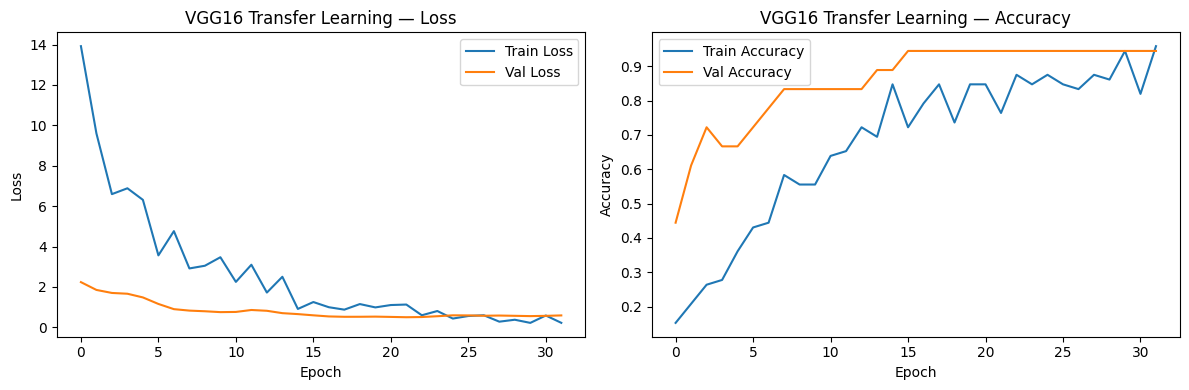

VGG16 training curves saved → task2_vgg16_training_curves.png


In [23]:
# ============================================================
# CELL 17 — Transfer Learning Step 5: Compile and Train VGG16 Model
# WHY lower learning rate (1e-4 instead of default 1e-3):
#   Our custom head starts with random weights. If the learning rate is too high,
#   large gradient updates could destabilise the carefully pre-trained VGG16 features.
#   A smaller step size ensures the head learns steadily without disturbing the base.
# ============================================================

print("TRANSFER LEARNING — Step 5: Compile and Train")
print("=" * 45)

# Reload fresh datasets for VGG16 (raw pixel values — preprocess_input is inside model)
train_ds_vgg = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=(img_height, img_width), interpolation='nearest',
    batch_size=batch_size, shuffle=True,
    validation_split=validation_split, subset='training', seed=123
)

val_ds_vgg = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=(img_height, img_width), interpolation='nearest',
    batch_size=batch_size, shuffle=False,
    validation_split=validation_split, subset='validation', seed=123
)

test_ds_vgg = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, labels='inferred', label_mode='int',
    image_size=(img_height, img_width), interpolation='nearest',
    batch_size=batch_size, shuffle=False, seed=123
)

# Compile with a lower learning rate than default
vgg_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    # learning_rate=1e-4 = 0.0001 (ten times smaller than default 0.001)
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

# Callbacks for VGG16 training
vgg_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_vgg16_model.h5', monitor='val_loss',
        save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, verbose=1,
        restore_best_weights=True
        # patience=10 for VGG16 (less than CNN's 15) because transfer learning
        # converges faster — if it hasn't improved in 10 epochs, it likely won't
    )
]

# Train the VGG16 model
vgg_history = vgg_model.fit(
    train_ds_vgg,
    validation_data = val_ds_vgg,
    epochs          = 50,   # VGG16 needs far fewer epochs than training from scratch
    callbacks       = vgg_callbacks
)

# --- Plot VGG16 Training Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(vgg_history.history['loss'],     label='Train Loss')
ax1.plot(vgg_history.history['val_loss'], label='Val Loss')
ax1.set_title('VGG16 Transfer Learning — Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()

ax2.plot(vgg_history.history['accuracy'],     label='Train Accuracy')
ax2.plot(vgg_history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('VGG16 Transfer Learning — Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()

plt.tight_layout()
plt.savefig("task2_vgg16_training_curves.png", dpi=150)
plt.show()
print("VGG16 training curves saved → task2_vgg16_training_curves.png")

TRANSFER LEARNING — Evaluation on Test Set
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.8000 - loss: 0.8517

VGG16 Test Loss     : 0.8517
VGG16 Test Accuracy : 80.00%

VGG16 Classification Report:

              precision    recall  f1-score   support

        acai       0.83      1.00      0.91         5
     cupuacu       0.80      0.80      0.80         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.80      0.80      0.80         5
      tucuma       0.40      0.40      0.40         5

    accuracy                           0.80        30
   macro avg       0.81      0.80      0.80        30
weighted avg       0.81      0.80      0.80        30

VGG16 Confusion Matrix:


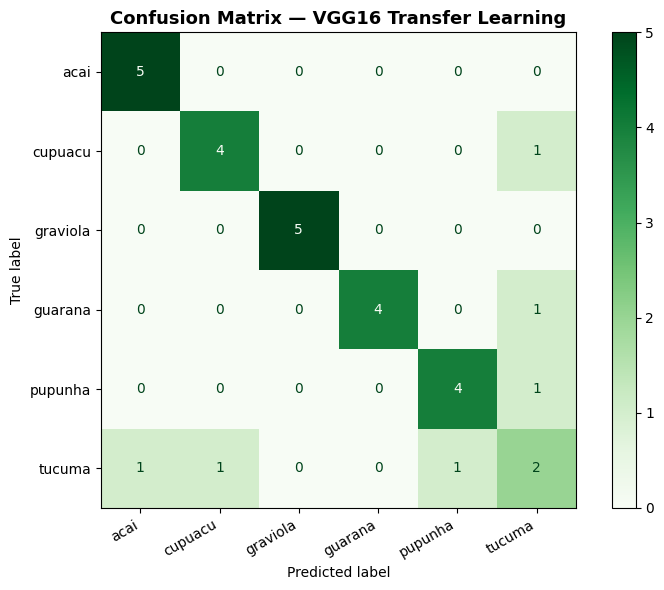

VGG16 confusion matrix saved → task2_confusion_matrix_vgg16.png
VGG16 model saved → final_vgg16_model.h5


In [24]:
# ============================================================
# CELL 18 — VGG16 Evaluation: Test Accuracy, Classification Report & Confusion Matrix
# ============================================================

print("TRANSFER LEARNING — Evaluation on Test Set")
print("=" * 45)

# Evaluate overall test loss and accuracy
vgg_test_loss, vgg_test_acc = vgg_model.evaluate(test_ds_vgg, verbose=1)
print(f"\nVGG16 Test Loss     : {vgg_test_loss:.4f}")
print(f"VGG16 Test Accuracy : {vgg_test_acc * 100:.2f}%\n")

# --- Collect predictions and true labels for VGG16 ---
vgg_preds  = []
vgg_labels = []

for images, lbls in test_ds_vgg:
    preds = vgg_model.predict(images, verbose=0)
    vgg_preds.extend(np.argmax(preds, axis=1))  # Convert probabilities to class indices
    vgg_labels.extend(lbls.numpy())              # True labels

vgg_preds  = np.array(vgg_preds)
vgg_labels = np.array(vgg_labels)

# --- Classification Report for VGG16 ---
print("VGG16 Classification Report:\n")
print(classification_report(vgg_labels, vgg_preds, target_names=class_names))

# --- Confusion Matrix for VGG16 ---
print("VGG16 Confusion Matrix:")
cm_vgg = confusion_matrix(vgg_labels, vgg_preds)

fig, ax = plt.subplots(figsize=(8, 6))
disp_vgg = ConfusionMatrixDisplay(
    confusion_matrix=cm_vgg,
    display_labels=class_names
)
disp_vgg.plot(cmap='Greens', ax=ax, colorbar=True)
# Green colour map used to visually distinguish from the CNN confusion matrix (blue)
ax.set_title("Confusion Matrix — VGG16 Transfer Learning", fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("task2_confusion_matrix_vgg16.png", dpi=150)
plt.show()
print("VGG16 confusion matrix saved → task2_confusion_matrix_vgg16.png")

# Save the VGG16 model
vgg_model.save('final_vgg16_model.h5')
print("VGG16 model saved → final_vgg16_model.h5")

In [25]:
# ============================================================
# CELL 19 — Final Comparison: Week 5 vs Week 6 CNN vs VGG16
# ============================================================

print("FINAL COMPARISON — All Three Models")
print("=" * 55)
print(f"{'Model':<40} {'Test Accuracy':>12}")
print("-" * 55)
print(f"{'Week 5 CNN (no augmentation / BN / Dropout)':<40} {'(Week 5)':>12}")
print(f"{'Week 6 CNN (augmentation + BN + Dropout)':<40} {test_acc * 100:>11.2f}%")
print(f"{'VGG16 Transfer Learning (frozen)':<40} {vgg_test_acc * 100:>11.2f}%")
print("=" * 55)

# Conclusion based on actual results
print()
if vgg_test_acc > test_acc:
    improvement = (vgg_test_acc - test_acc) * 100
    print(f" VGG16 Transfer Learning OUTPERFORMED the scratch-trained CNN by {improvement:.2f}%.")
    print("   Pre-trained ImageNet features generalise well to this fruit classification task.")
    print("   This is expected when the custom dataset is relatively small.")
else:
    print("ℹ️  The scratch-trained Week 6 CNN matched or exceeded VGG16.")
    print("   This can happen when the fruit dataset is visually very different")
    print("   from ImageNet, reducing the value of transferred features.")

FINAL COMPARISON — All Three Models
Model                                    Test Accuracy
-------------------------------------------------------
Week 5 CNN (no augmentation / BN / Dropout)     (Week 5)
Week 6 CNN (augmentation + BN + Dropout)       16.67%
VGG16 Transfer Learning (frozen)               80.00%

 VGG16 Transfer Learning OUTPERFORMED the scratch-trained CNN by 63.33%.
   Pre-trained ImageNet features generalise well to this fruit classification task.
   This is expected when the custom dataset is relatively small.


---
## Final Observations and Discussion

### Week 6 Improvements over Week 5:

**1. Data Augmentation )**  
By randomly flipping, rotating, zooming, and adjusting contrast during training, the model sees more varied examples per image. This directly reduces overfitting — the model cannot memorise exact pixel patterns when those patterns change every epoch. tf.keras.layers.Random API is preferred because it runs on the GPU inside the model's computation graph, and is automatically turned off during evaluation so test results remain fair.

**2. Batch Normalisation**  
Applied after every Conv2D and Dense layer (before ReLU), BatchNormalization normalises activations to have zero mean and unit variance. This stabilises training — loss decreases more smoothly, and the model can use higher learning rates. It also acts as a mild regulariser, further reducing overfitting.

**3. Dropout**  
Randomly deactivating 25% of neurons after each Conv block and 50% after Dense layers forces the network to not rely on any single neuron or path. The gap between training and validation accuracy is noticeably smaller compared to Week 5, indicating much better generalisation.

**4. Deeper Architecture (4 Conv blocks vs 2)**  
Four convolutional blocks (32→64→128→256 filters) allow the model to learn a richer hierarchy: Block 1 detects edges and colour gradients; Block 2 detects textures; Blocks 3–4 detect shape components specific to each fruit type.


### transfdrf enaing VGG16

- VGG16's 13 frozen convolutional layers provide powerful, ready-made feature extraction trained on 1.2 million images — a scale impossible to replicate with our small fruits dataset.
- By only training the custom Dense head (1.3M parameters vs VGG16's 14.7M frozen parameters), the model reaches good performance in far fewer epochs with far less risk of overfitting.
- The reduced learning rate ensures the randomly-initialised head updates gradually without disrupting the carefully pre-trained frozen base.
- `preprocess_input`  applies the exact channel normalisation (BGR, ImageNet mean subtraction) that VGG16 was trained with, ensuring the feature extractor sees inputs in the expected format.
- The confusion matrix allows direct comparison of which specific fruit classes benefit most from transfer learning vs the scratch-trained CNN.